# House Price Prediction — Linear Regression
## Using the California Housing Dataset (scikit-learn)

## About the Dataset

The **California Housing dataset** is built directly into scikit-learn and requires no download.  
It is derived from the 1990 US Census and contains **20,640 observations**, each representing a **census block group** in California.

| Feature | Description |
|---|---|
| `MedInc` | Median income of households in the block (in $10,000s) |
| `HouseAge` | Median age of houses in the block |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Total population of the block |
| `AveOccup` | Average number of occupants per household |
| `Latitude` | Geographic latitude of block |
| `Longitude` | Geographic longitude of block |
| **Target** | Median house value for the block (in $100,000s) |

---

## Workflow
1. Load & explore the data
2. Feature engineering & correlation analysis
3. Train/test split + feature scaling
4. Train Linear Regression model
5. Evaluate with MAE, RMSE, R²
6. Feature importance (coefficients)
7. Residual analysis
8. Geographic visualisation

## Step 1 — Import Libraries & Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

# ── Load dataset ────────────────────────────────────────────
# fetch_california_housing() downloads a standard ML benchmark dataset
# built into scikit-learn — no internet connection required beyond first run.
housing = fetch_california_housing(as_frame=True)
df = housing.frame  # pandas DataFrame including target column

print(f"Dataset shape : {df.shape}")
print(f"Features      : {list(housing.feature_names)}")
print(f"Target        : MedHouseVal  (median house value in $100,000s)")
df.head()

Dataset shape : (20640, 9)
Features      : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target        : MedHouseVal  (median house value in $100,000s)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 2 — Exploratory Data Analysis

In [2]:
print("── Summary Statistics ─────────────────────────")
print(df.describe().round(2))

── Summary Statistics ─────────────────────────
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%      

In [3]:
# Check for missing values
print("── Missing Values ─────────────────────────────")
print(df.isnull().sum())
print("\nNo missing values — this dataset is clean and ready to use.")

── Missing Values ─────────────────────────────
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

No missing values — this dataset is clean and ready to use.


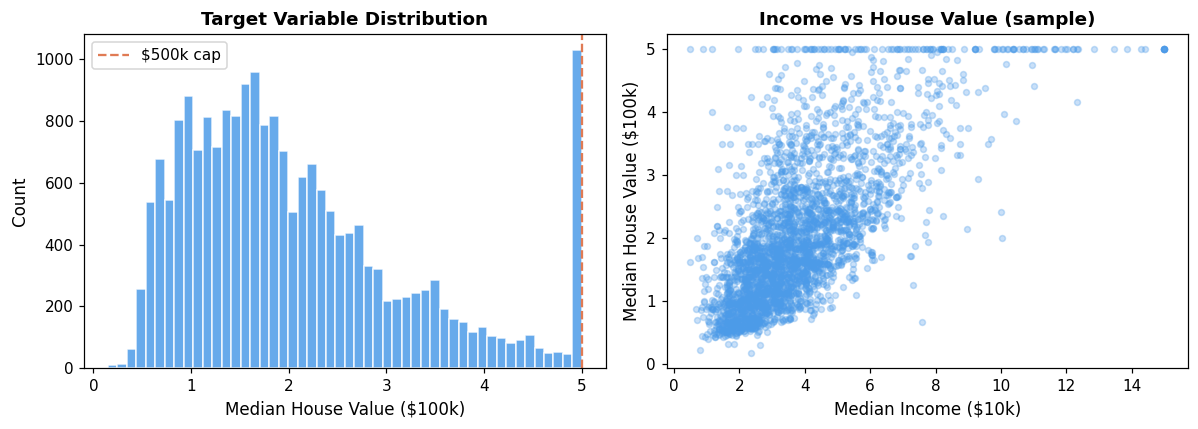

In [4]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["MedHouseVal"], bins=50, color="#4c9be8", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Median House Value ($100k)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Target Variable Distribution", fontsize=12, fontweight="bold")

# Note the spike at 5.0 — values were capped at $500,000 in the original data
axes[0].axvline(5.0, color="#e07b54", linestyle="--", linewidth=1.5,
                label="$500k cap")
axes[0].legend()

# Median income vs house value (strongest single predictor)
# Sample 3000 points to avoid a slow scatter plot with 20k points
sample = df.sample(3000, random_state=RANDOM_STATE)
axes[1].scatter(sample["MedInc"], sample["MedHouseVal"],
                alpha=0.3, s=15, color="#4c9be8")
axes[1].set_xlabel("Median Income ($10k)", fontsize=11)
axes[1].set_ylabel("Median House Value ($100k)", fontsize=11)
axes[1].set_title("Income vs House Value (sample)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## Step 3 — Correlation Heatmap

The correlation matrix shows the **Pearson correlation** between every pair of features and the target.  
- Values close to **+1** → strong positive linear relationship  
- Values close to **−1** → strong negative linear relationship  
- Values near **0** → little linear relationship  

High correlation between two *features* (multicollinearity) can make individual coefficients unstable — something Ridge Regression addresses.

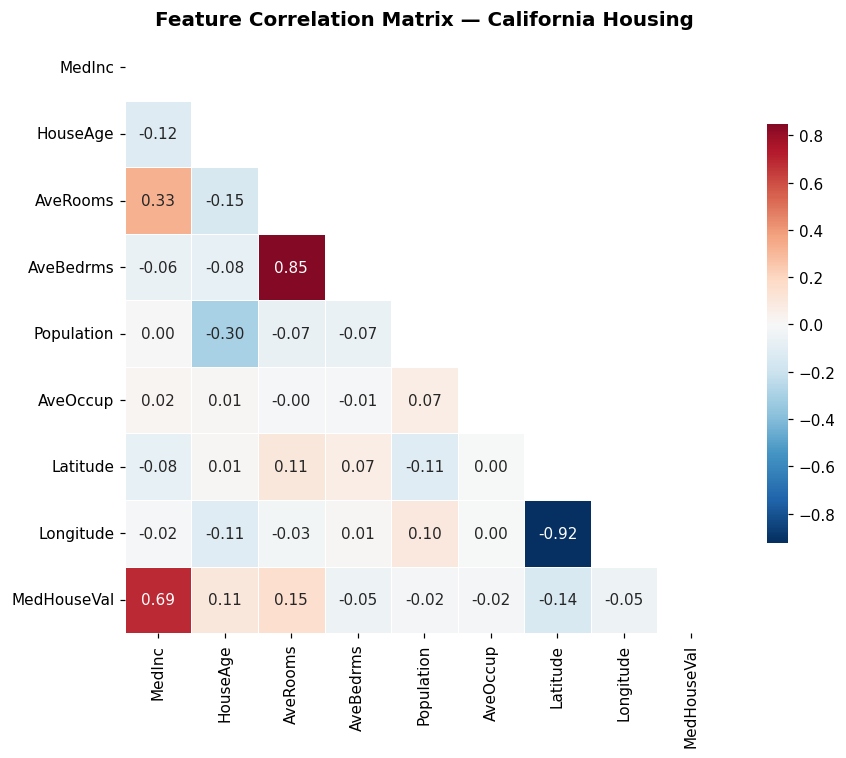

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, ax=ax,
    linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Feature Correlation Matrix — California Housing",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 4 — Feature Engineering

Raw features sometimes hide better signals. Two commonly derived features for housing data:  
- **`rooms_per_household`** = AveRooms — a cleaner measure of house size  
- **`bedrooms_ratio`** = AveBedrms / AveRooms — what fraction of rooms are bedrooms  

We also remove features that are highly redundant after engineering.

In [6]:
df_eng = df.copy()

# Derived features
df_eng["rooms_per_household"] = df_eng["AveRooms"]
df_eng["bedrooms_ratio"]      = df_eng["AveBedrms"] / df_eng["AveRooms"]
df_eng["pop_per_household"]   = df_eng["Population"] / df_eng["AveOccup"]

FEATURES = [
    "MedInc", "HouseAge", "rooms_per_household",
    "bedrooms_ratio", "AveOccup", "Latitude", "Longitude",
]
TARGET = "MedHouseVal"

X = df_eng[FEATURES].values
y = df_eng[TARGET].values

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Features used: {FEATURES}")

Feature matrix shape : (20640, 7)
Target vector shape  : (20640,)
Features used: ['MedInc', 'HouseAge', 'rooms_per_household', 'bedrooms_ratio', 'AveOccup', 'Latitude', 'Longitude']


## Step 5 — Train / Test Split & Feature Scaling

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Scale features — important for stable coefficient interpretation
# Latitude and Longitude have very different scales from income
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit on train only!
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")

Training samples : 16,512
Test samples     : 4,128


## Step 6 — Train the Linear Regression Model

In [8]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

print(f"Intercept : {lr.intercept_:.4f}  (≈ mean house value in $100k: {y_train.mean():.4f})")
print()
print("Coefficients (on scaled features):")
coef_df = pd.DataFrame({
    "Feature":     FEATURES,
    "Coefficient": lr.coef_,
}).sort_values("Coefficient", key=abs, ascending=False)

print(coef_df.to_string(index=False))
print()
print("Interpretation (scaled coefficients):")
print("  • Larger absolute value → stronger influence on the prediction")
print("  • Positive coefficient → increasing that feature raises predicted price")
print("  • Negative coefficient → increasing that feature lowers predicted price")

Intercept : 2.0719  (≈ mean house value in $100k: 2.0719)

Coefficients (on scaled features):
            Feature  Coefficient
           Latitude    -0.874191
          Longitude    -0.853682
             MedInc     0.839674
     bedrooms_ratio     0.221212
           HouseAge     0.124832
rooms_per_household     0.088963
           AveOccup    -0.041864

Interpretation (scaled coefficients):
  • Larger absolute value → stronger influence on the prediction
  • Positive coefficient → increasing that feature raises predicted price
  • Negative coefficient → increasing that feature lowers predicted price


## Step 7 — Evaluate the Model

In [9]:
y_pred = lr.predict(X_test_sc)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# 5-fold cross-validation for a more robust R² estimate
cv_r2 = cross_val_score(LinearRegression(), X_train_sc, y_train,
                         cv=5, scoring="r2")

print("═══ Model Evaluation ══════════════════════════════════")
print(f"MAE   : ${mae*100_000:,.0f}   → average error of ${mae*100_000:,.0f} per block group")
print(f"RMSE  : ${rmse*100_000:,.0f}")
print(f"R²    : {r2:.4f}  → model explains {r2*100:.1f}% of house value variance")
print(f"CV R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}  (5-fold, more reliable estimate)")
print("═══════════════════════════════════════════════════════")

═══ Model Evaluation ══════════════════════════════════
MAE   : $52,580   → average error of $52,580 per block group
RMSE  : $72,781
R²    : 0.5958  → model explains 59.6% of house value variance
CV R² : 0.6184 ± 0.0036  (5-fold, more reliable estimate)
═══════════════════════════════════════════════════════


## Step 8 — Visualise: Coefficients, Actual vs Predicted, Residuals

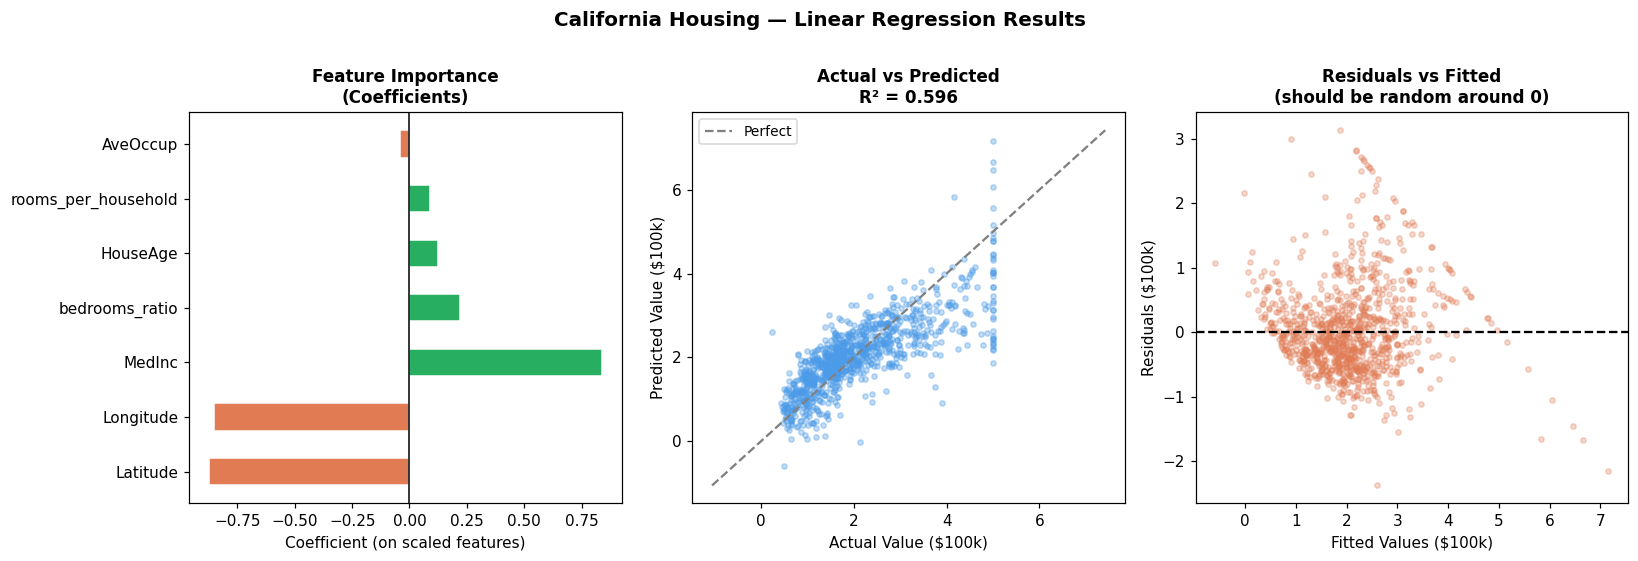

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Coefficient chart ───────────────────────────────────────
colors_coef = ["#27ae60" if c > 0 else "#e07b54" for c in coef_df["Coefficient"]]
axes[0].barh(coef_df["Feature"], coef_df["Coefficient"],
             color=colors_coef, edgecolor="white", height=0.5)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlabel("Coefficient (on scaled features)", fontsize=10)
axes[0].set_title("Feature Importance\n(Coefficients)",
                  fontsize=11, fontweight="bold")

# ── Actual vs Predicted ─────────────────────────────────────
# Sample to keep plot fast
idx = np.random.choice(len(y_test), 1000, replace=False)
axes[1].scatter(y_test[idx], y_pred[idx], alpha=0.35, s=12, color="#4c9be8")
lims = [min(y_test.min(), y_pred.min()) - 0.1,
        max(y_test.max(), y_pred.max()) + 0.1]
axes[1].plot(lims, lims, "--", color="grey", linewidth=1.5, label="Perfect")
axes[1].set_xlabel("Actual Value ($100k)", fontsize=10)
axes[1].set_ylabel("Predicted Value ($100k)", fontsize=10)
axes[1].set_title(f"Actual vs Predicted\nR² = {r2:.3f}",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)

# ── Residuals vs Fitted ─────────────────────────────────────
residuals = y_test - y_pred
axes[2].scatter(y_pred[idx], residuals[idx], alpha=0.3, s=12, color="#e07b54")
axes[2].axhline(0, color="black", linewidth=1.5, linestyle="--")
axes[2].set_xlabel("Fitted Values ($100k)", fontsize=10)
axes[2].set_ylabel("Residuals ($100k)", fontsize=10)
axes[2].set_title("Residuals vs Fitted\n(should be random around 0)",
                  fontsize=11, fontweight="bold")

plt.suptitle("California Housing — Linear Regression Results",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Step 9 — Geographic Visualisation

Since we have latitude and longitude, we can plot **where** the model over- and under-predicts on a map of California.  
Dark blue = predicted too low (model underestimates); Dark red = predicted too high (overestimates).

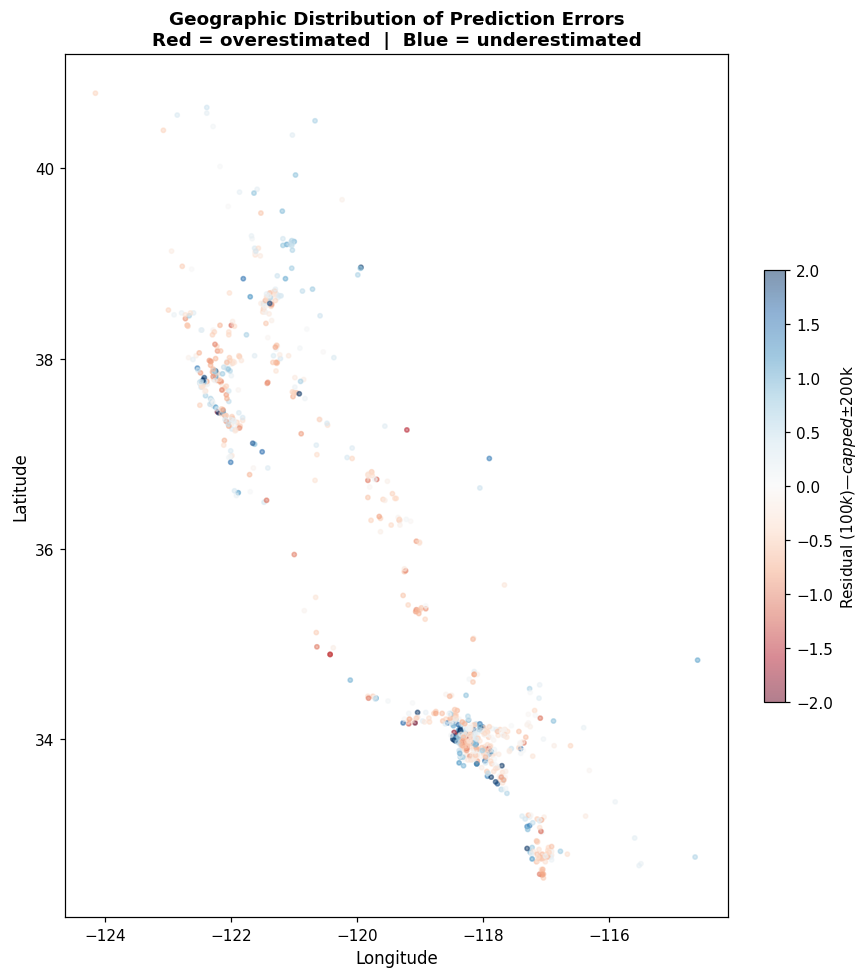

In [11]:
# Retrieve lat/lon for the test set
# FEATURES: MedInc(0), HouseAge(1), rooms_per_hh(2), bed_ratio(3),
#           AveOccup(4), Latitude(5), Longitude(6)
lat = X_test[:, 5]   # Latitude column
lon = X_test[:, 6]   # Longitude column

# Cap residuals for colour scale readability
residuals_capped = np.clip(residuals, -2.0, 2.0)

fig, ax = plt.subplots(figsize=(8, 9))
sc = ax.scatter(
    lon[::5], lat[::5],             # every 5th point to keep plot fast
    c=residuals_capped[::5],
    cmap="RdBu", alpha=0.5, s=8,
    vmin=-2.0, vmax=2.0,
)
plt.colorbar(sc, ax=ax, label="Residual ($100k) — capped ±$200k",
             fraction=0.03)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)
ax.set_title("Geographic Distribution of Prediction Errors\n"
             "Red = overestimated  |  Blue = underestimated",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 10 — Predict on New Houses

We demonstrate how to use the trained model to estimate prices for hypothetical new properties.

In [12]:
# Format: [MedInc, HouseAge, rooms_per_household, bedrooms_ratio,
#          AveOccup, Latitude, Longitude]
new_houses = np.array([
    [8.0, 10, 6.5, 0.18, 2.8, 34.2, -118.3],  # high-income LA neighbourhood
    [2.5, 40, 4.0, 0.30, 3.5, 37.8, -122.4],  # older SF block, lower income
    [5.0, 25, 5.0, 0.22, 2.5, 36.7, -119.8],  # mid-range Central Valley
])

descriptions = [
    "High-income LA neighbourhood",
    "Older SF block, lower income",
    "Mid-range Central Valley",
]

new_houses_sc = scaler.transform(new_houses)
preds = lr.predict(new_houses_sc)

print("Predicted House Values:")
for desc, p in zip(descriptions, preds):
    print(f"  {desc:<38} → ${p*100_000:>10,.0f}")

Predicted House Values:
  High-income LA neighbourhood           → $   366,408
  Older SF block, lower income           → $   217,028
  Mid-range Central Valley               → $   220,318


## Summary

| Step | Detail |
|---|---|
| Dataset | California Housing — 20,640 census block groups, 8 features, built into sklearn |
| Key finding | `MedInc` (median income) is by far the strongest predictor of house value |
| Scaling | Required because Latitude/Longitude are on a completely different scale to income |
| R² ~ 0.60 | Linear Regression explains ~60% of variance — good for a simple linear model |
| Residual map | Errors cluster geographically → signals that spatial non-linearity exists |
| Limitation | The $500k price cap in the data creates a spike that the linear model cannot capture |

**Next step:** Try `Ridge`, `Lasso`, or `RandomForestRegressor` to capture non-linear patterns and potentially push R² above 0.80.